# 1. Model10の動作テスト

In [1]:
import os

os.chdir('/home/hashikami/projects/Diff')

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.nn.functional as F
import itertools
from tqdm.auto import tqdm


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/root/.local/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/root/.local/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/root/.local/lib/python3.10/site-packages/ipykernel/kerne

## 1.1 学習前の条件付き生成実験

sampling loop time step: 100%|██████████| 500/500 [00:10<00:00, 46.24it/s]


RuntimeError: Numpy is not available

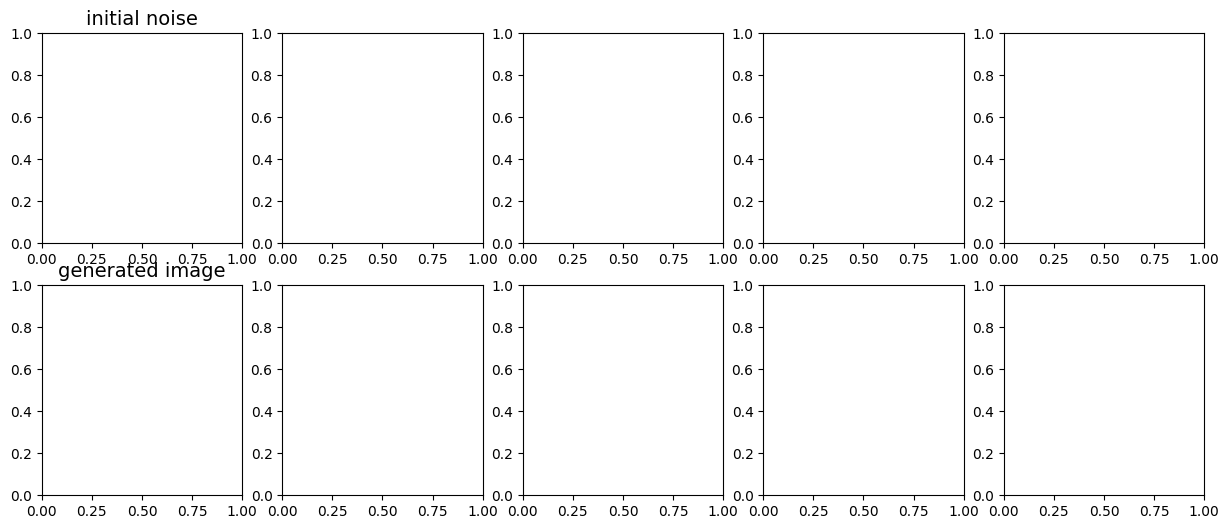

In [5]:
from diffusion.diffusion_model.models import model10
import importlib

importlib.reload(model10)

from diffusion.diffusion_model.models.model10 import UNet
from diffusion.utils.sample import conditional_ddim_plot_samples


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
denoise_model = UNet().to(device)
cond = torch.randn(5, 2).to(device)

conditional_ddim_plot_samples(denoise_model, eta=1.0, interval=1, cond=cond, w=0.1, batch_size=5, image_size=28, timesteps=500)

### 探索的なエラー解析

In [15]:
import torch.nn as nn

cdim = 2
tdim = 64
cond = torch.randn(10, 2)

class CondEmbedShared(nn.Module):
    """
    K個の条件y_kをそれぞれ独立にout_dim次元に埋め込む
    """
    def __init__(self, num_cond:int, out_dim:int):
        super().__init__()
        self.emb = nn.ModuleList([
            nn.Sequential(nn.Linear(1, out_dim), nn.SiLU(), nn.Linear(out_dim, out_dim)) for _ in range(num_cond)
        ])
    def forward(self, cond:torch.Tensor) -> torch.Tensor:
        # cond: (b, num_cond)
        out = [m(cond[:, i:i+1]) for i, m in enumerate(self.emb)] # num_cond個 [(b, out_dim), ..]
        return torch.stack(out, dim=1) # (b, num_cond, out_dim)
    
cemb_layer = CondEmbedShared(cdim, tdim)
cemb = cemb_layer(cond)

In [17]:
mod_ch = 4
out_dim = mod_ch * tdim
num_cond = 2
emb = nn.ModuleList([
    nn.Sequential(nn.Linear(1, out_dim), nn.SiLU(), nn.Linear(out_dim, out_dim)) for _ in range(num_cond)
])

out = [m(cond[:, i:i+1]) for i, m in enumerate(emb)]
out = torch.stack(out, dim=1)
out.shape

torch.Size([10, 2, 256])

In [22]:
out_ch = 128

cemb_proj = nn.ModuleList([
    nn.Sequential(nn.SiLU(), nn.Linear(tdim, out_ch)) for _ in range(num_cond)
])
add = 0
for i in range(num_cond):
    add += cemb_proj[i](cemb[:, i:i+1].squeeze(1))
    
add.shape
    

torch.Size([10, 128])

## 1.2 再構成実験

sampling loop time step: 100%|██████████| 500/500 [00:10<00:00, 45.53it/s]


平均二乗誤差: 2.959068536758423


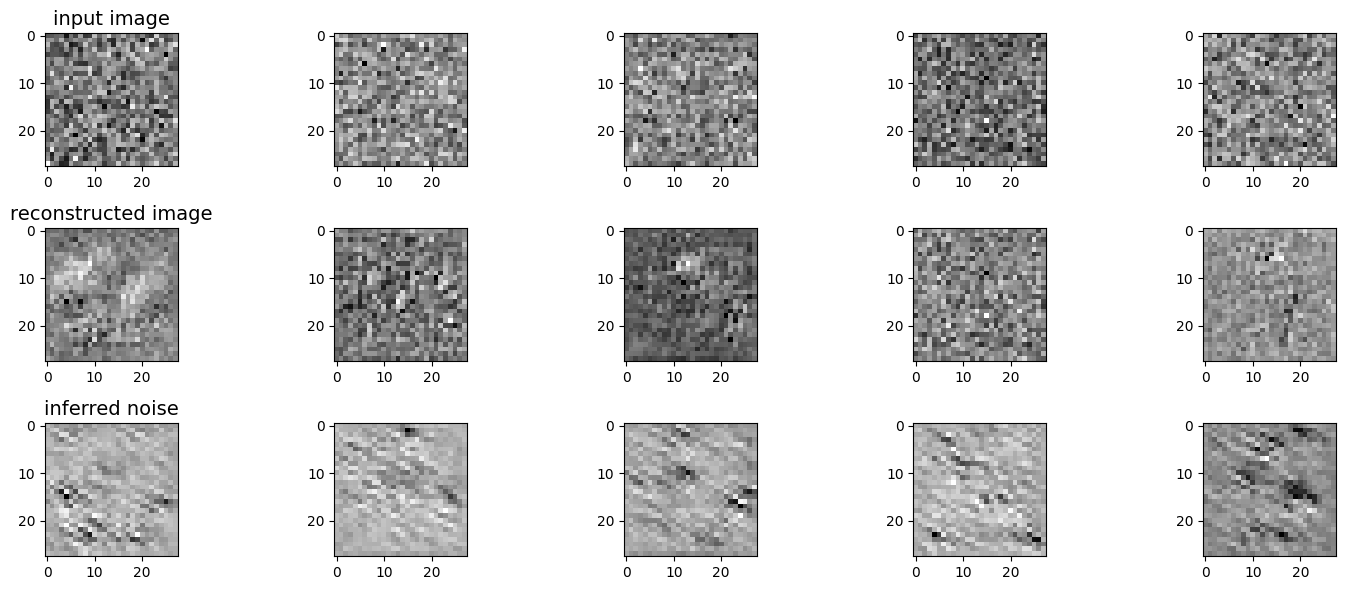

In [28]:
input_img = torch.randn(5, 1, 32, 32).to(device)
cond = torch.randn(5, 2).to(device)
intervened_cond = torch.randn(5, 2).to(device)

conditional_ddim_plot_samples(denoise_model, eta=0.0, interval=1, cond=cond, w=0.1, batch_size=5, image_size=28, timesteps=500, reverse=True, input_img=input_img, intervened_cond=intervened_cond)

# 2. 拡散モデルを用いた反事実的画像編集

In [1]:
import os

os.chdir('/home/hashikami/projects/Diff')

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.nn.functional as F
import itertools
from tqdm.auto import tqdm

/home/hashikami/projects/Diff/.venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/hashikami/projects/Diff/.venv/lib/python3.8/site-packages/torchvision/io/image.py:11: UserWarning: Failed to load image Python extension: /home/hashikami/projects/Diff/.venv/lib/python3.8/site-packages/torchvision/image.so: undefined symbol: _ZNK3c1010TensorImpl36is_contiguous_nondefault_policy_implENS_12MemoryFormatE
  warn(f"Failed to load image Python extension: {e}")


In [3]:
from diffusion.diffusion_model.models.model10 import UNet
from diffusion.utils.utils import load_checkpoint
import json


# 実験設定ファイルパス
file_path = "/home/hashikami/results/2025-07-15_17/config_20250715.json"
with open(file_path, mode='r') as f:
    config = json.load(f)


epochs = config['epochs']
timesteps = config['timesteps']
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
denoise_model = UNet().to(device)
optimizer = optim.Adam(denoise_model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[int(epochs * ratio) for ratio in [0.5, 0.8]],
    gamma=0.2
)

In [4]:
# checkpointの読み込み
denoise_model, optimizer, scheduler, start_epoch, loss = load_checkpoint(denoise_model, optimizer, scheduler, filename='/home/hashikami/checkpoint/checkpoint_2025-07-15_19.pth')

In [ ]:
# metricsのサンプルを取得

import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from dataset.morphomnist import MorphoMNISTLike
from diffusion.utils.utils import resize_images

# Example usage
batch_size = 1
dataset = MorphoMNISTLike(root_dir="/home/hashikami/datadrive/MorphoMNIST",
                            columns=['intensity', 'thickness'], train=False)
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
intensity = next(iter(data_loader))['intensity'][:, None].float()
thickness = next(iter(data_loader))['thickness'][:, None].float()
metrics = torch.cat([intensity, thickness], dim=1).to(device)
images = next(iter(data_loader))['image'].unsqueeze(1) / 255.0 # 値のスケールに注意せよ
images = resize_images(images, (32, 32)).squeeze(1)


"""
fig, axes = plt.subplots(1, batch_size, figsize=(15, 3))
for i in range(batch_size):
    axes[i].imshow(images[i].squeeze(), cmap='gray')
plt.show()
print(metrics)
"""

/home/hashikami/projects/Diff/.venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/hashikami/projects/Diff/dataset/morphomnist.py:90: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:199.)
  self.images = torch.as_tensor(images)


NameError: name 'torch' is not defined

## 1.1 条件付き生成

sampling loop time step: 100%|██████████| 500/500 [00:10<00:00, 45.95it/s]


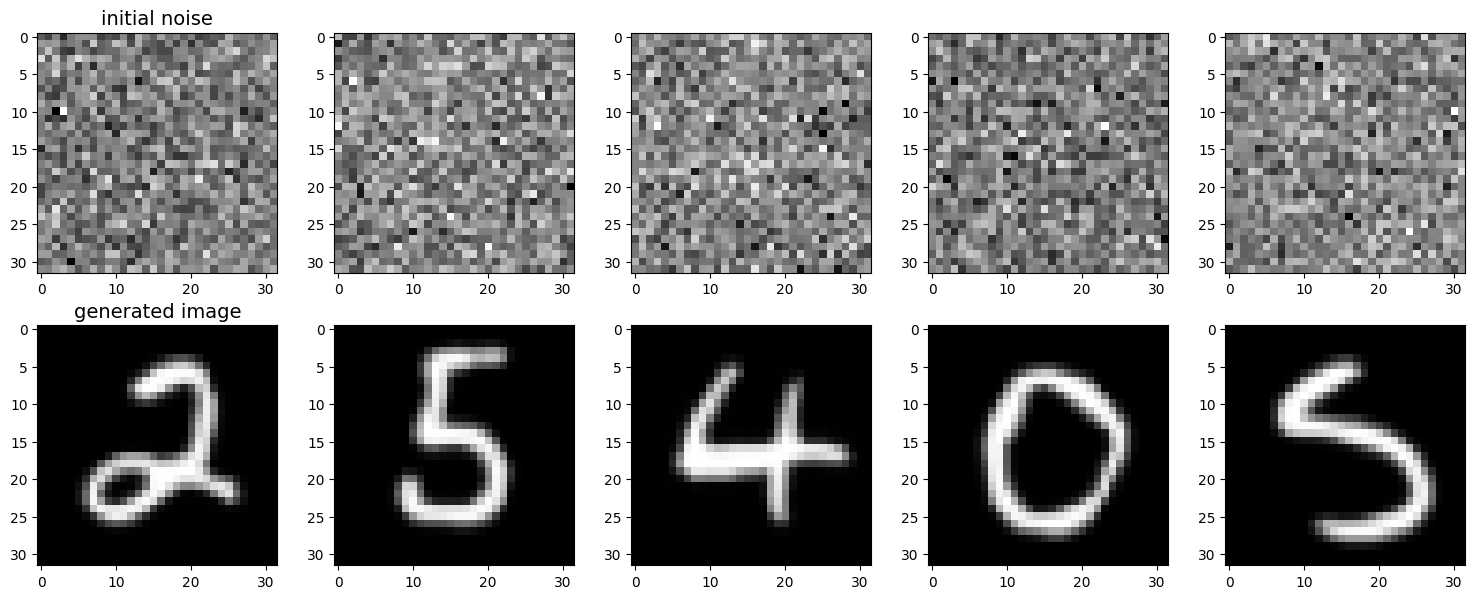

In [6]:
import importlib
from diffusion.utils import sample

importlib.reload(sample)

from diffusion.utils.sample import conditional_ddim_plot_samples


conditional_ddim_plot_samples(denoise_model, eta=0.0, interval=1, cond=metrics, w=0.1, image_size=32, batch_size=5, timesteps=500)

## 1.2 介入後条件付き画像編集

### 1.2.1 複数枚で編集

### 1.2.2 1枚の画像をガイダンススケール固定で様々な介入条件で編集

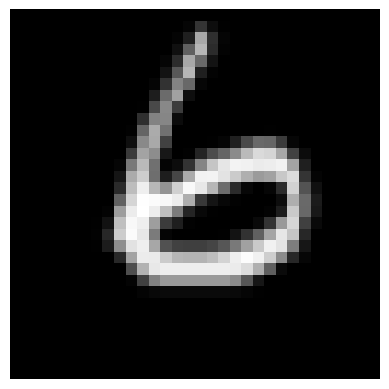

In [7]:
plt.imshow(images[0].squeeze(), cmap='gray')
plt.axis('off')
plt.show()


In [8]:
def make_value_lists(t, a, b, num_steps=5):
    """
    (1,2)形状のtorch.tensor t から2つの値を取り出し、
    1つ目の値については正の値aで加算・減算を繰り返して等間隔のリストを作り、
    2つ目の値については正の値bで同様にリストを作る。

    Returns:
        intensity_values, thickness_values
    """
    first_value = t[0][0].item()
    second_value = t[0][1].item()
    intensity_values = [round(first_value - (num_steps//2 - i)*a, 4) for i in range(num_steps)]
    thickness_values = [round(second_value - (num_steps//2 - i)*b, 4) for i in range(num_steps)]
    return intensity_values, thickness_values

In [11]:
intensity_values, thickness_values = make_value_lists(metrics, 10, 0.5, num_steps=5)

In [ ]:
from diffusion.utils.diffusion_utils import DiffusionUtils
import numpy as np

eta=0.5
interval=1
cond=metrics
w=1.0
batch_size=1
image_size=32
timesteps=500
input_img=images.unsqueeze(1).to(device)
utils = DiffusionUtils(timesteps=timesteps)

# 5×5のリスト
editted_images = [[] for _ in range(len(intensity_values))]
for i in range(len(intensity_values)):
    for j in range(len(thickness_values)):
        intervened_metrics = torch.Tensor([[intensity_values[i], thickness_values[j]]]).to(device)
        noises = utils.ddim_p_sample_loop(denoise_model, eta, interval, metrics, w, image_size=image_size, batch_size=batch_size, channels=1, reverse=True, input_img=input_img)
        imgs = utils.ddim_p_sample_loop(denoise_model, eta, interval, intervened_metrics, w, image_size=image_size, batch_size=batch_size, channels=1, reverse=False, noise=noises[-1])
        editted_images[i].append(imgs[-1].cpu().detach().numpy())
        
def generate_intervened_images(
    denoise_model, input_img, intensity_values, thickness_values,
    eta, interval, w, image_size, timesteps
):
    """
    入力画像と条件値リストに対して、各条件値で介入した画像を生成する。

    Args:
        denoise_model: 学習済み拡散モデル
        input_img: (B, 1, H, W) もしくは (1, 1, H, W) のtorch.Tensor
        intensity_values: 介入するintensity値のリスト
        thickness_values: 介入するthickness値のリスト
        eta: DDIMのノイズパラメータ
        interval: DDIMのステップ間隔
        w: guidance scale
        image_size: 画像サイズ
        timesteps: 拡散ステップ数

    Returns:
        edited_images: 2次元リスト [i][j] で intensity_values[i], thickness_values[j] で介入した画像
    """
    import torch
    from diffusion.utils.diffusion_utils import DiffusionUtils

    device = input_img.device if hasattr(input_img, "device") else "cpu"
    batch_size = 1
    channels = 1

    utils = DiffusionUtils(timesteps=timesteps)
    edited_images = [[] for _ in range(len(intensity_values))]
    # 介入前の条件値（input_imgに対応するmetrics）を推定する必要がある場合は引数で渡すこと
    for i, intensity in enumerate(intensity_values):
        for j, thickness in enumerate(thickness_values):
            intervened_metrics = torch.tensor([[intensity, thickness]], dtype=torch.float32, device=device)
            # まずinput_imgからノイズ系列を推定
            noises = utils.ddim_p_sample_loop(
                denoise_model, eta, interval, intervened_metrics, w,
                image_size=image_size, batch_size=batch_size, channels=channels,
                reverse=True, input_img=input_img
            )
            # そのノイズから介入条件で画像を生成
            imgs = utils.ddim_p_sample_loop(
                denoise_model, eta, interval, intervened_metrics, w,
                image_size=image_size, batch_size=batch_size, channels=channels,
                reverse=False, noise=noises[-1]
            )
            edited_images[i].append(imgs[-1].cpu().detach().numpy())
    return edited_images


In [21]:
from diffusion.utils.diffusion_utils import DiffusionUtils
import numpy as np

eta=0.5
interval=1
cond=metrics
w=1.0
batch_size=1
image_size=32
timesteps=500
input_img=images.unsqueeze(1).to(device)
utils = DiffusionUtils(timesteps=timesteps)

# 5×5のリスト
editted_images = [[] for _ in range(len(intensity_values))]
for i in range(len(intensity_values)):
    for j in range(len(thickness_values)):
        intervened_metrics = torch.Tensor([[intensity_values[i], thickness_values[j]]]).to(device)
        noises = utils.ddim_p_sample_loop(denoise_model, eta, interval, metrics, w, image_size=image_size, batch_size=batch_size, channels=1, reverse=True, input_img=input_img)
        imgs = utils.ddim_p_sample_loop(denoise_model, eta, interval, intervened_metrics, w, image_size=image_size, batch_size=batch_size, channels=1, reverse=False, noise=noises[-1])
        editted_images[i].append(imgs[-1].cpu().detach().numpy())

sampling loop time step:   0%|          | 0/500 [00:00<?, ?it/s]

sampling loop time step: 100%|██████████| 500/500 [00:09<00:00, 51.54it/s]


#### 画像のスケールを可視化

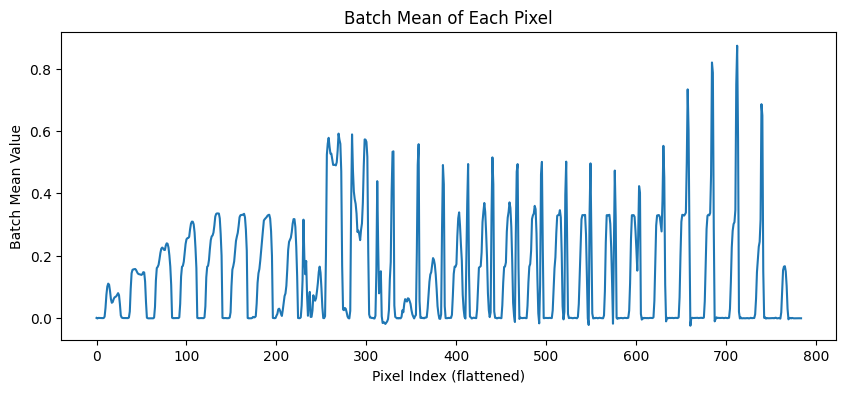

In [59]:
import matplotlib.pyplot as plt
import torch

def visualize_batch_pixel_mean(images):
    """
    (B, C, H, W)の画像テンソル（C=1）について、
    横軸：ピクセル位置（flattenしたインデックス or 0~H*W-1）
    縦軸：バッチ全体での各ピクセルの平均値
    """
    if isinstance(images, torch.Tensor):
        images_np = images.cpu().numpy()
    else:
        images_np = images
    # images_np: (B, 1, H, W)
    B, C, H, W = images_np.shape
    # flatten (B, 1, H, W) -> (B, H*W)
    images_flat = images_np.reshape(B, -1)
    # バッチ方向に平均
    mean_pixel = images_flat.mean(axis=0)  # shape: (H*W,)
    plt.figure(figsize=(10, 4))
    plt.plot(mean_pixel)
    plt.xlabel("Pixel Index (flattened)")
    plt.ylabel("Batch Mean Value")
    plt.title("Batch Mean of Each Pixel")
    plt.show()

# 例: editted_imagesの一部を可視化
# editted_imagesは2次元リストなので、例えばeditted_images[0][0]などをまとめて可視化
# ここでは全ての画像をまとめて可視化する例
all_imgs = []
for row in editted_images:
    for img in row:
        img = img.squeeze(0)
        all_imgs.append(img)
all_imgs = np.stack(all_imgs)  # shape: (N, 1, H, W)
visualize_batch_pixel_mean(torch.from_numpy(all_imgs))

#### 画像のスケールを0-1から0-255に変換

In [22]:
def scale_image_0_1_to_0_255(image):
    """
    画像の各ピクセル値を0~1スケールから0~255スケールに変換する関数

    Args:
        image (np.ndarray or torch.Tensor): 0~1スケールの画像

    Returns:
        np.ndarray or torch.Tensor: 0~255スケールの画像（同じ型で返す）
    """
    if isinstance(image, torch.Tensor):
        return (image * 255).clamp(0, 255).to(torch.uint8)
    else:
        return np.clip(image * 255, 0, 255).astype(np.uint8)

# edited_imagesの各要素（画像）を0~255スケールに変換
edited_images_255 = [
    [scale_image_0_1_to_0_255(img) for img in row]
    for row in editted_images
]

images_255 = scale_image_0_1_to_0_255(images)

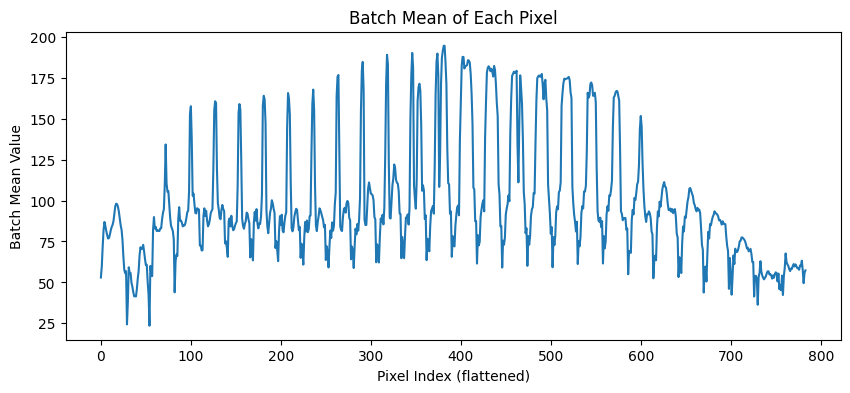

In [77]:

all_imgs_255 = []
for row in edited_images_255:
    for img in row:
        img = img.squeeze(0)
        all_imgs_255.append(img)
all_imgs_255 = np.stack(all_imgs_255)  # shape: (N, 1, H, W)
visualize_batch_pixel_mean(torch.from_numpy(all_imgs_255))

In [23]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_edit_grid(input_image, edited_images, brightness_values, thickness_values):
    """
    入力画像と編集済み画像のグリッドを可視化（各画像に明るさ・太さの値を表示）

    Args:
        input_image (ndarray): 入力画像（1枚）shape: [H, W] or [1, H, W]
        edited_images (2D list): 2次元リスト [thickness_i][brightness_j] の画像
        brightness_values (list): 横軸（明るさ）の値
        thickness_values (list): 縦軸（太さ）の値
    """
    n_thick = len(thickness_values)
    n_bright = len(brightness_values)
    fig, axes = plt.subplots(n_thick, n_bright, figsize=(2 * n_bright, 2.5 * n_thick))

    for i in range(n_bright):
        for j in range(n_thick):
            ax = axes[i, j]
            ax.axis('off')
            if i == n_bright // 2 and j == n_thick // 2:
                # 真ん中：入力画像
                ax.imshow(np.squeeze(input_image), cmap='gray')
                ax.set_title(f"Original, I: {brightness_values[i]:.2f}\nT: {thickness_values[j]:.2f}", fontsize=8)
                ax.set_xlabel(f"I: {brightness_values[i]:.2f}\nT: {thickness_values[j]:.2f}", fontsize=6)
            else:
                ax.imshow(np.squeeze(edited_images[i][j]), cmap='gray')
                ax.set_title(f"I: {brightness_values[i]:.2f}\nT: {thickness_values[j]:.2f}", fontsize=6)

    # 下と左に補足
    fig.text(0.5, -0.05, '→ Thickness increases', ha='center', fontsize=10)
    fig.text(-0.05, 0.5, '← Intensity increases', va='center', rotation='vertical', fontsize=10)

    plt.tight_layout()
    plt.show()


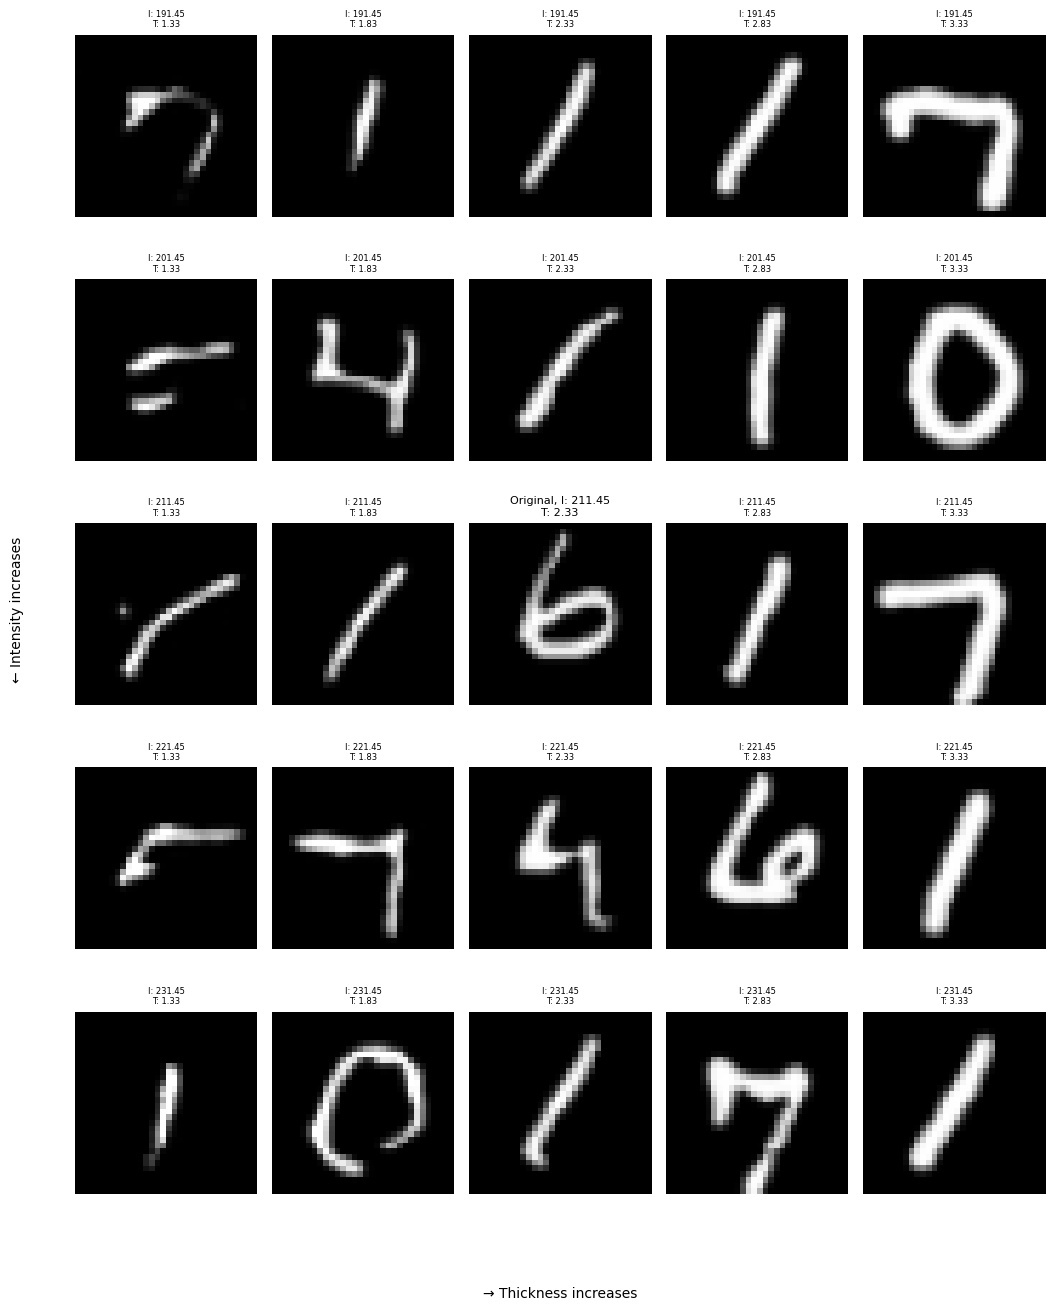

In [24]:
visualize_edit_grid(images_255, edited_images_255, intensity_values, thickness_values)